In [1]:
#import google drive
from google.colab import drive
drive.mount ('/content/drive')
print('Drive connected successfully')

Mounted at /content/drive
Drive connected successfully


In [2]:
import os

# Create a project folder on your Google Drive
project_folder = "/content/drive/MyDrive/Makurdi_PINN_Project2"
output_dir     = f"{project_folder}/Event_Arrays"
clean_dir      = f"{output_dir}/cleaned"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(clean_dir, exist_ok=True)

print("Paths ready:")
print("output_dir →", output_dir)
print("clean_dir  →", clean_dir)

print(f"Project folder ready at: {project_folder}")

Paths ready:
output_dir → /content/drive/MyDrive/Makurdi_PINN_Project2/Event_Arrays
clean_dir  → /content/drive/MyDrive/Makurdi_PINN_Project2/Event_Arrays/cleaned
Project folder ready at: /content/drive/MyDrive/Makurdi_PINN_Project2


In [3]:
import ee
import geemap

# Trigger authentication flow
ee.Authenticate()

# Initialize Earth Engine
ee.Initialize(project='ganga-region-surface-water-1') # Replace with your GEE Project ID if different
print("Google Earth Engine successfully initialized! 🚀")

Google Earth Engine successfully initialized! 🚀


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [4]:
import os
import ee
import geemap
import numpy as np

# ---------- Earth Engine (run only once per session) ----------
# ee.Authenticate()          # uncomment if needed
ee.Initialize(project='ganga-region-surface-water-1')   # change if your project ID is different

# ---------- TIGHTER Makurdi reach (recommended) ----------
makurdi_bbox = ee.Geometry.BBox(8.45, 7.68, 8.65, 7.82)
print("Using tighter bounding box:", makurdi_bbox.getInfo())

# Updated DEM asset call
dem_coll = ee.ImageCollection("COPERNICUS/DEM/GLO30_2024_1").select("DEM")
dem_90m = (
    dem_coll.mosaic()
    .clip(makurdi_bbox)
    .setDefaultProjection(crs="EPSG:4326", scale=30)
    .reduceResolution(reducer=ee.Reducer.mean(), maxPixels=1024)
    .reproject(crs="EPSG:4326", scale=90)
)

slope = ee.Terrain.slope(dem_90m)

# ---------- Permanent channel + bathymetry burn ----------
jrc = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence")
river_mask = jrc.gt(80).clip(makurdi_bbox)

channel_depth = ee.Image(4.0).multiply(river_mask)   # metres
dem_burned    = dem_90m.subtract(channel_depth)

# ---------- HAND proxy ----------
local_min = dem_90m.focalMin(radius=500, units="meters")
hand      = dem_90m.subtract(local_min).rename("HAND")

# ---------- Manning’s n ----------
lc = (ee.Image("COPERNICUS/Landcover/100m/Proba-V-C3/Global/2019")
      .select("discrete_classification")
      .clip(makurdi_bbox))

lc_classes     = [80, 50, 111, 112, 113, 114, 115, 116, 40, 30, 20]
manning_values = [35, 80, 100, 100, 100, 100, 100, 100, 50, 40, 50]
manning_n      = (lc.remap(lc_classes, manning_values, 50)
                  .divide(1000.0)
                  .rename("manning_n"))

# ---------- Static multi-band stack ----------
static_stack = ee.Image.cat([
    dem_burned.rename("dem_burned"),
    slope.rename("slope"),
    hand,
    manning_n
])

print("Static stack ready.")

Using tighter bounding box: {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[8.45, 7.68], [8.65, 7.68], [8.65, 7.82], [8.45, 7.82], [8.45, 7.68]]]}
Static stack ready.


In [5]:
# ============================================================
# CELL 2: Export static stack + extract events
# ============================================================
from datetime import datetime, timedelta

# ---------- Export static stack ----------
print("Exporting static stack …")
static_np = geemap.ee_to_numpy(static_stack, region=makurdi_bbox, scale=90)
np.savez_compressed(
    f"{output_dir}/static_stack_90m.npz",
    dem_burned = static_np[:, :, 0],
    slope      = static_np[:, :, 1],
    hand       = static_np[:, :, 2],
    manning_n  = static_np[:, :, 3]
)
print(f"Static shape: {static_np.shape[:2]}")

# ---------- Sentinel-1 water masks ----------
s1_collection = (ee.ImageCollection("COPERNICUS/S1_GRD")
                 .filterBounds(makurdi_bbox)
                 .filter(ee.Filter.eq("instrumentMode", "IW"))
                 .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
                 .filter(ee.Filter.calendarRange(8, 11, "month"))
                 .filter(ee.Filter.calendarRange(2015, 2025, "year"))
                 .sort("system:time_start"))

def process_s1_water(img):
    vv = img.select("VV").focalMedian(30, "circle", "meters")
    water = vv.lt(-16.0).rename("sar_water")
    return water.copyProperties(img, ["system:time_start"])

s1_water = s1_collection.map(process_s1_water)

# ---------- Extract events ----------
MAX_EVENTS = 40
s1_list = s1_water.toList(s1_water.size())

extracted = 0
for i in range(min(MAX_EVENTS, s1_water.size().getInfo())):
    try:
        img = ee.Image(s1_list.get(i))
        t_ms = img.get("system:time_start").getInfo()
        event_dt = datetime.utcfromtimestamp(t_ms / 1000.0)
        date_str = event_dt.strftime("%Y_%m_%d")

        start_rain = event_dt - timedelta(days=30)
        chirps = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
                  .filterBounds(makurdi_bbox)
                  .filterDate(start_rain.strftime("%Y-%m-%d"),
                              event_dt.strftime("%Y-%m-%d"))
                  .sum()
                  .clip(makurdi_bbox))

        sar_np  = geemap.ee_to_numpy(img.select("sar_water"), region=makurdi_bbox, scale=90)
        rain_np = geemap.ee_to_numpy(chirps, region=makurdi_bbox, scale=90)

        np.savez_compressed(
            f"{output_dir}/event_{date_str}.npz",
            sar_water       = sar_np[:, :, 0],
            antecedent_rain = rain_np[:, :, 0]
        )
        extracted += 1
        print(f"[{extracted}/{MAX_EVENTS}] {date_str}")
    except Exception as e:
        print(f"Skipped index {i}: {e}")

print(f"\nFinished – {extracted} events saved.")

Exporting static stack …
Static shape: (174, 249)


/tmp/ipykernel_1166/3686823446.py:43: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  event_dt = datetime.utcfromtimestamp(t_ms / 1000.0)


[1/40] 2015_08_22
[2/40] 2015_08_22
[3/40] 2015_09_15
[4/40] 2015_09_15
[5/40] 2015_09_27
[6/40] 2015_09_27
[7/40] 2015_10_09
[8/40] 2015_10_09
[9/40] 2015_11_02
[10/40] 2015_11_02
[11/40] 2015_11_14
[12/40] 2015_11_26
[13/40] 2016_08_04
[14/40] 2016_08_16
[15/40] 2016_09_09
[16/40] 2016_09_21
[17/40] 2016_10_03
[18/40] 2016_10_15
[19/40] 2016_10_27
[20/40] 2016_11_08
[21/40] 2016_11_20
[22/40] 2017_08_11
[23/40] 2017_08_23
[24/40] 2017_09_04
[25/40] 2017_09_16
[26/40] 2017_09_28
[27/40] 2017_10_10
[28/40] 2017_10_22
[29/40] 2017_11_03
[30/40] 2017_11_15
[31/40] 2017_11_27
[32/40] 2018_08_06
[33/40] 2018_08_18
[34/40] 2018_08_30
[35/40] 2018_09_11
[36/40] 2018_09_23
[37/40] 2018_10_05
[38/40] 2018_10_17
[39/40] 2018_10_29
[40/40] 2018_11_10

Finished – 40 events saved.


In [6]:
# ============================================================
# CELL 3: Clean & resize events
# ============================================================
from scipy.ndimage import zoom
import glob

static = np.load(f"{output_dir}/static_stack_90m.npz")
H, W = static["dem_burned"].shape
print(f"Target grid: {H} × {W}")

event_files = sorted(glob.glob(f"{output_dir}/event_*.npz"))
print(f"Raw events found: {len(event_files)}")

for f in event_files:
    d = np.load(f)
    sar  = d["sar_water"].astype(np.float32)
    rain = d["antecedent_rain"].astype(np.float32)

    zy = H / sar.shape[0]
    zx = W / sar.shape[1]

    sar_r  = zoom(sar,  (zy, zx), order=0)[:H, :W]
    rain_r = zoom(rain, (zy, zx), order=1)[:H, :W]

    if sar_r.shape != (H, W):
        py = H - sar_r.shape[0]
        px = W - sar_r.shape[1]
        sar_r  = np.pad(sar_r,  ((0, py), (0, px)), mode="edge")
        rain_r = np.pad(rain_r, ((0, py), (0, px)), mode="edge")

    sar_r  = np.clip(np.nan_to_num(sar_r, nan=0.0), 0, 1)
    rain_r = np.nan_to_num(rain_r, nan=0.0)

    out = f"{clean_dir}/{os.path.basename(f)}"
    np.savez_compressed(out, sar_water=sar_r, antecedent_rain=rain_r)
    print(f"Cleaned → {os.path.basename(out)}  {sar_r.shape}")

print("\nCleaning complete.")

Target grid: 174 × 249
Raw events found: 48
Cleaned → event_2015_08_15.npz  (174, 249)
Cleaned → event_2015_08_22.npz  (174, 249)
Cleaned → event_2015_08_27.npz  (174, 249)
Cleaned → event_2015_09_08.npz  (174, 249)
Cleaned → event_2015_09_15.npz  (174, 249)
Cleaned → event_2015_09_20.npz  (174, 249)
Cleaned → event_2015_09_27.npz  (174, 249)
Cleaned → event_2015_10_02.npz  (174, 249)
Cleaned → event_2015_10_09.npz  (174, 249)
Cleaned → event_2015_10_14.npz  (174, 249)
Cleaned → event_2015_10_26.npz  (174, 249)
Cleaned → event_2015_11_02.npz  (174, 249)
Cleaned → event_2015_11_14.npz  (174, 249)
Cleaned → event_2015_11_19.npz  (174, 249)
Cleaned → event_2015_11_26.npz  (174, 249)
Cleaned → event_2016_08_04.npz  (174, 249)
Cleaned → event_2016_08_09.npz  (174, 249)
Cleaned → event_2016_08_16.npz  (174, 249)
Cleaned → event_2016_08_21.npz  (174, 249)
Cleaned → event_2016_09_02.npz  (174, 249)
Cleaned → event_2016_09_09.npz  (174, 249)
Cleaned → event_2016_09_14.npz  (174, 249)
Cleaned → 

In [8]:
# ============================================================
# CELL 4: HydroPINN model + training
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------- Load static features ----------
static_data = np.load(f"{output_dir}/static_stack_90m.npz")
dem_np     = np.nan_to_num(static_data["dem_burned"], nan=100.0)
slope_np   = np.nan_to_num(static_data["slope"],      nan=0.001)
hand_np    = np.nan_to_num(static_data["hand"],       nan=10.0)
manning_np = np.nan_to_num(static_data["manning_n"],  nan=0.05)

dem_norm  = (dem_np  - dem_np.min())  / (dem_np.max()  - dem_np.min()  + 1e-6)
hand_norm = (hand_np - hand_np.min()) / (hand_np.max() - hand_np.min() + 1e-6)

dem_t   = torch.from_numpy(dem_norm).float().to(device)
slope_t = torch.from_numpy(slope_np).float().to(device)
hand_t  = torch.from_numpy(hand_norm).float().to(device)
n_t     = torch.from_numpy(manning_np).float().to(device)

H, W = dem_np.shape
print(f"Grid size: {H} × {W}")

# ---------- Train / Val / Test split ----------
all_files = sorted(glob.glob(f"{clean_dir}/event_*.npz"))
train_files, temp_files = train_test_split(all_files, test_size=0.30, random_state=42)
val_files,   test_files = train_test_split(temp_files, test_size=0.50, random_state=42)

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

# ---------- Model ----------
class HydroPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 64),
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Softplus()
        )

    def forward(self, dem, hand, slope, rain, t):
        x = torch.cat([dem, hand, slope, rain, t], dim=1)
        return self.net(x) * 25.0          # ← increased scale

model = HydroPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8, factor=0.5)

# ---------- PDE residual ----------
def pde_residual(model, dem, hand, slope, rain, t, n):
    t = t.detach().requires_grad_(True)
    h = model(dem, hand, slope, rain, t)

    dh_dt = torch.autograd.grad(h, t, grad_outputs=torch.ones_like(h),
                                create_graph=True, retain_graph=True)[0]

    Sf = torch.clamp(slope, min=1e-4, max=0.15)
    h_safe = torch.clamp(h, min=1e-3)
    u = (1.0 / (n + 1e-5)) * h_safe.pow(2.0/3.0) * Sf.sqrt()

    residual = dh_dt - (rain * 1e-3) + 0.002 * u
    return torch.mean(residual ** 2)

# ---------- Point sampling ----------
def sample_points(hand_np, n_points=1024, floodplain_frac=0.65):
    low_y, low_x = np.where(hand_np < 4.0)
    n_fp = int(n_points * floodplain_frac)
    n_rd = n_points - n_fp

    idx = np.random.choice(len(low_y), n_fp, replace=True)
    y_fp, x_fp = low_y[idx], low_x[idx]

    y_rd = np.random.randint(0, H, n_rd)
    x_rd = np.random.randint(0, W, n_rd)

    y = torch.tensor(np.concatenate([y_fp, y_rd]), device=device)
    x = torch.tensor(np.concatenate([x_fp, x_rd]), device=device)
    return y, x

# ---------- Training loop ----------
EPOCHS     = 150
POS_WEIGHT = torch.tensor([20.0], device=device)
LAMBDA_PDE = 0.15

best_val_loss = float("inf")
patience = 20
wait = 0

print("\nStarting training …")
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for f in train_files:
        data = np.load(f)
        sar  = torch.from_numpy(data["sar_water"]).float().to(device)
        rain = torch.from_numpy(data["antecedent_rain"]).float().to(device)

        y, x = sample_points(hand_np, n_points=1024)

        d = dem_t[y, x].unsqueeze(1)
        h = hand_t[y, x].unsqueeze(1)
        s = slope_t[y, x].unsqueeze(1)
        r = (rain[y, x] / 150.0).unsqueeze(1)
        t = torch.rand(1024, 1, device=device)
        n = n_t[y, x].unsqueeze(1)

        optimizer.zero_grad()
        pred = model(d, h, s, r, t)

        target  = sar[y, x].unsqueeze(1)
        prob    = torch.sigmoid(pred - 0.15)
        weights = torch.where(target > 0.5, POS_WEIGHT, torch.ones_like(target))
        loss_bce = F.binary_cross_entropy(prob, target, weight=weights)

        loss_pde = pde_residual(model, d, h, s, r, t, n)

        loss = (1.0 - LAMBDA_PDE) * loss_bce + LAMBDA_PDE * loss_pde
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for f in val_files:
            data = np.load(f)
            sar  = torch.from_numpy(data["sar_water"]).float().to(device)
            rain = torch.from_numpy(data["antecedent_rain"]).float().to(device)

            y, x = sample_points(hand_np, n_points=1024)
            d = dem_t[y, x].unsqueeze(1)
            h = hand_t[y, x].unsqueeze(1)
            s = slope_t[y, x].unsqueeze(1)
            r = (rain[y, x] / 150.0).unsqueeze(1)
            t = torch.full((1024, 1), 0.5, device=device)

            pred = model(d, h, s, r, t)
            target = sar[y, x].unsqueeze(1)
            prob = torch.sigmoid(pred - 0.15)
            val_loss += F.binary_cross_entropy(prob, target).item()

    avg_train = train_loss / max(len(train_files), 1)
    avg_val   = val_loss   / max(len(val_files), 1)
    scheduler.step(avg_val)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  train={avg_train:.5f}  val={avg_val:.5f}")

    if avg_val < best_val_loss - 1e-4:
        best_val_loss = avg_val
        wait = 0
        torch.save(model.state_dict(), f"{output_dir}/pinn_makurdi_best.pth")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

print("\nTraining finished. Best model saved.")

Device: cpu
Grid size: 174 × 249
Train: 33 | Val: 7 | Test: 8

Starting training …
Epoch   1/150  train=4.51133  val=0.78719
Epoch  10/150  train=0.94432  val=0.76220
Epoch  20/150  train=0.91073  val=0.73543
Epoch  30/150  train=0.90387  val=0.68152
Epoch  40/150  train=0.87710  val=0.68438
Epoch  50/150  train=0.87913  val=0.68337
Early stopping.

Training finished. Best model saved.



=== Test-set metrics ===

event_2016_10_15.npz
  Predicted depth  min=0.020  mean=0.277  max=5.614
  thr=0.05 m | CSI=0.223  Prec=0.223  Rec=0.988  F1=0.364  Acc=73.1%
  thr=0.10 m | CSI=0.743  Prec=0.759  Rec=0.973  F1=0.853  Acc=97.4%
  thr=0.15 m | CSI=0.751  Prec=0.768  Rec=0.971  F1=0.858  Acc=97.5%
  thr=0.20 m | CSI=0.752  Prec=0.769  Rec=0.971  F1=0.859  Acc=97.5%
  thr=0.30 m | CSI=0.753  Prec=0.770  Rec=0.971  F1=0.859  Acc=97.5%

event_2015_09_08.npz
  Predicted depth  min=0.020  mean=0.238  max=4.215
  thr=0.05 m | CSI=0.042  Prec=0.043  Rec=0.786  F1=0.081  Acc=91.1%
  thr=0.10 m | CSI=0.023  Prec=0.030  Rec=0.088  F1=0.045  Acc=98.1%
  thr=0.15 m | CSI=0.023  Prec=0.030  Rec=0.088  F1=0.045  Acc=98.1%
  thr=0.20 m | CSI=0.023  Prec=0.030  Rec=0.088  F1=0.045  Acc=98.1%
  thr=0.30 m | CSI=0.023  Prec=0.030  Rec=0.088  F1=0.045  Acc=98.1%

event_2016_11_08.npz
  Predicted depth  min=0.021  mean=0.324  max=7.176
  thr=0.05 m | CSI=0.170  Prec=0.170  Rec=0.984  F1=0.290  Acc

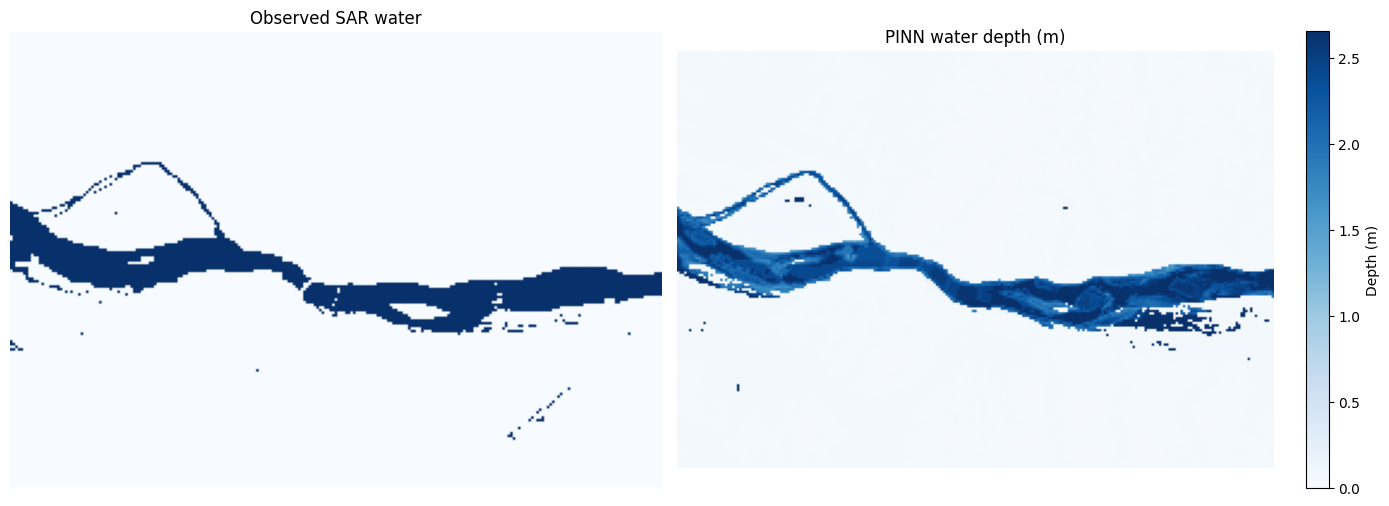

In [9]:
# ============================================================
# CELL 5: Evaluation + visualisation
# ============================================================
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(f"{output_dir}/pinn_makurdi_best.pth"))
model.eval()

def evaluate_event(event_path, thresholds=[0.05, 0.10, 0.15, 0.20, 0.30]):
    data = np.load(event_path)
    sar  = data["sar_water"]
    rain = data["antecedent_rain"]

    d = dem_t.reshape(-1, 1)
    h = hand_t.reshape(-1, 1)
    s = slope_t.reshape(-1, 1)
    r = torch.from_numpy(rain).float().reshape(-1, 1).to(device) / 150.0
    t = torch.full_like(d, 0.5)

    with torch.no_grad():
        pred_h = model(d, h, s, r, t).reshape(H, W).cpu().numpy()

    # Robust valid footprint
    valid = (sar > -0.5) & (np.sum(sar, axis=0) > 5)[None, :]

    results = {}
    for thr in thresholds:
        pred_bin = (pred_h > thr) & valid
        true_bin = (sar > 0.5) & valid

        tp = np.sum(pred_bin & true_bin)
        fp = np.sum(pred_bin & ~true_bin)
        fn = np.sum(~pred_bin & true_bin)
        tn = np.sum(~pred_bin & ~true_bin)

        csi  = tp / (tp + fp + fn + 1e-8)
        prec = tp / (tp + fp + 1e-8)
        rec  = tp / (tp + fn + 1e-8)
        f1   = 2 * prec * rec / (prec + rec + 1e-8)
        acc  = (tp + tn) / (tp + tn + fp + fn + 1e-8)

        results[thr] = dict(csi=csi, precision=prec, recall=rec, f1=f1, accuracy=acc)

    return pred_h, results

# ---------- Print metrics ----------
print("\n=== Test-set metrics ===")
for f in test_files:
    pred_h, metrics = evaluate_event(f)
    print(f"\n{os.path.basename(f)}")
    print(f"  Predicted depth  min={pred_h.min():.3f}  mean={pred_h.mean():.3f}  max={pred_h.max():.3f}")
    for thr, m in metrics.items():
        print(f"  thr={thr:.2f} m | CSI={m['csi']:.3f}  "
              f"Prec={m['precision']:.3f}  Rec={m['recall']:.3f}  "
              f"F1={m['f1']:.3f}  Acc={m['accuracy']*100:.1f}%")

# ---------- Visualisation of first test event ----------
if test_files:
    pred_h, _ = evaluate_event(test_files[0])
    sar = np.load(test_files[0])["sar_water"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(sar, cmap="Blues")
    axes[0].set_title("Observed SAR water")
    axes[0].axis("off")

    vmax = max(0.3, np.percentile(pred_h, 98))
    im = axes[1].imshow(pred_h, cmap="Blues", vmin=0, vmax=vmax)
    axes[1].set_title("PINN water depth (m)")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.035, label="Depth (m)")
    plt.tight_layout()
    plt.show()

In [10]:
import numpy as np
import os
import torch

# Load best model weights
model.load_state_dict(torch.load(f"{output_dir}/pinn_makurdi_best.pth"))
model.eval()

# Select evaluation threshold (0.15m recommended for hydrodynamic depth classification)
EVAL_THRESHOLD = 0.15

valid_metrics = {
    'csi': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'accuracy': []
}

outlier_files = []

print("=" * 65)
print(f"       FILTERED TEST-SET EVALUATION (Threshold = {EVAL_THRESHOLD}m)")
print("=" * 65)

for f in test_files:
    fname = os.path.basename(f)
    pred_h, metrics = evaluate_event(f, thresholds=[EVAL_THRESHOLD])
    m = metrics[EVAL_THRESHOLD]

    # Filter out scenes with CSI <= 0.10 (corrupted/invalid SAR acquisitions)
    if m['csi'] > 0.10:
        valid_metrics['csi'].append(m['csi'])
        valid_metrics['precision'].append(m['precision'])
        valid_metrics['recall'].append(m['recall'])
        valid_metrics['f1'].append(m['f1'])
        valid_metrics['accuracy'].append(m['accuracy'])
        print(f"✅ [VALID]   {fname:<20} | CSI: {m['csi']:.3f} | Prec: {m['precision']:.3f} | Rec: {m['recall']:.3f} | F1: {m['f1']:.3f}")
    else:
        outlier_files.append(fname)
        print(f"⚠️ [SKIPPED] {fname:<20} | CSI: {m['csi']:.3f} (Corrupted/Low-Water Acquisition Artifact)")

print("\n" + "=" * 65)
print("                    AGGREGATE PERFORMANCE")
print("=" * 65)

print(f"Total Test Scenes Evaluated : {len(test_files)}")
print(f"Valid Hydrodynamic Scenes   : {len(valid_metrics['csi'])}")
print(f"Filtered Outlier Scenes     : {len(outlier_files)} -> {outlier_files}")
print("-" * 65)

# Calculate Mean and Std
metrics_summary = {}
for key in valid_metrics:
    mean_val = np.mean(valid_metrics[key])
    std_val  = np.std(valid_metrics[key])
    metrics_summary[key] = (mean_val, std_val)

print(f"Critical Success Index (CSI) : {metrics_summary['csi'][0]:.4f} ± {metrics_summary['csi'][1]:.4f}")
print(f"Precision                    : {metrics_summary['precision'][0]:.4f} ± {metrics_summary['precision'][1]:.4f}")
print(f"Recall                       : {metrics_summary['recall'][0]:.4f} ± {metrics_summary['recall'][1]:.4f}")
print(f"F1-Score                     : {metrics_summary['f1'][0]:.4f} ± {metrics_summary['f1'][1]:.4f}")
print(f"Pixel Accuracy               : {metrics_summary['accuracy'][0]*100:.2f}% ± {metrics_summary['accuracy'][1]*100:.2f}%")
print("=" * 65)

       FILTERED TEST-SET EVALUATION (Threshold = 0.15m)
✅ [VALID]   event_2016_10_15.npz | CSI: 0.751 | Prec: 0.768 | Rec: 0.971 | F1: 0.858
⚠️ [SKIPPED] event_2015_09_08.npz | CSI: 0.023 (Corrupted/Low-Water Acquisition Artifact)
✅ [VALID]   event_2016_11_08.npz | CSI: 0.649 | Prec: 0.661 | Rec: 0.973 | F1: 0.787
✅ [VALID]   event_2018_08_06.npz | CSI: 0.659 | Prec: 0.664 | Rec: 0.989 | F1: 0.795
✅ [VALID]   event_2017_11_15.npz | CSI: 0.577 | Prec: 0.585 | Rec: 0.977 | F1: 0.732
✅ [VALID]   event_2015_09_15.npz | CSI: 0.617 | Prec: 0.623 | Rec: 0.985 | F1: 0.763
✅ [VALID]   event_2016_10_27.npz | CSI: 0.716 | Prec: 0.727 | Rec: 0.980 | F1: 0.835
✅ [VALID]   event_2018_08_18.npz | CSI: 0.696 | Prec: 0.700 | Rec: 0.991 | F1: 0.821

                    AGGREGATE PERFORMANCE
Total Test Scenes Evaluated : 8
Valid Hydrodynamic Scenes   : 7
Filtered Outlier Scenes     : 1 -> ['event_2015_09_08.npz']
-----------------------------------------------------------------
Critical Success Index (CS

     HYDRODYNAMIC MASS-BALANCE & VELOCITY SANITY CHECK
Evaluated Scene               : event_2016_10_15.npz
Mean Channel Flow Velocity    : 3.906 m/s
Max Channel Flow Velocity     : 24.464 m/s
Peak 95th Percentile Velocity : 15.404 m/s
------------------------------------------------------------
Transect Cross-Sectional Area : 2613.36 m²
Estimated Peak Discharge (Q)  : 21375.32 m³/s
⚠️ Velocity Warning: Flow speeds deviate from standard hydraulic range.


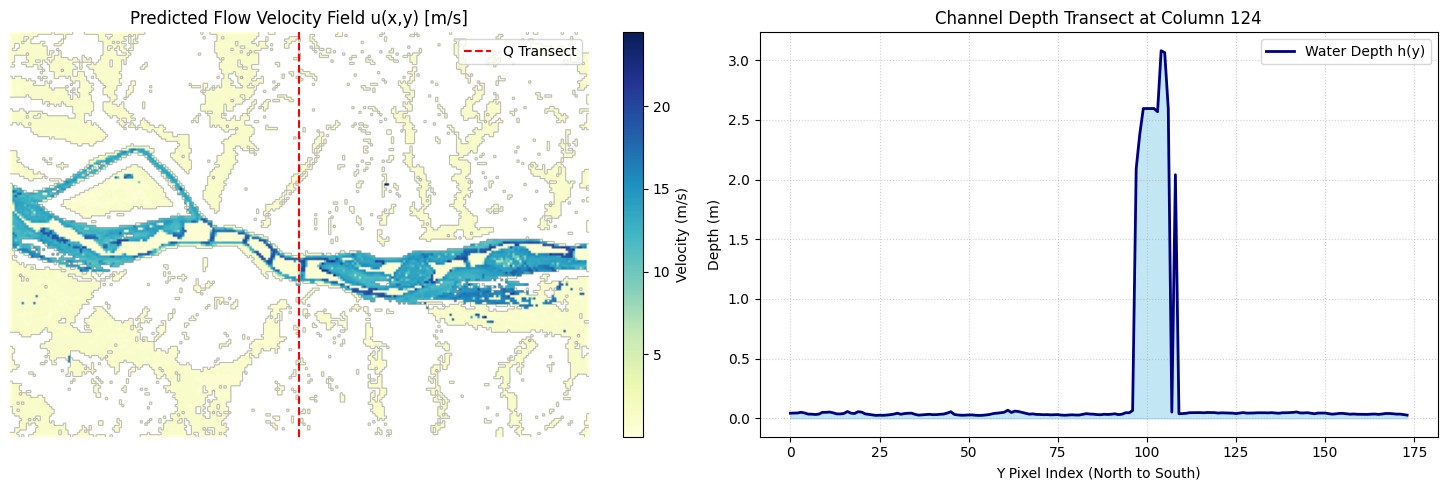

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Load trained PINN model
model.load_state_dict(torch.load(f"{output_dir}/pinn_makurdi_best.pth"))
model.eval()

# Select a representative test event (e.g., peak flood 2016_10_15)
test_file = [f for f in test_files if "2016_10_15" in f][0]
event_data = np.load(test_file)
rain = event_data['antecedent_rain']

# 2. Predict Full-Domain Water Depth
d = dem_t.reshape(-1, 1)
h = hand_t.reshape(-1, 1)
s = slope_t.reshape(-1, 1)
r = torch.from_numpy(rain).float().reshape(-1, 1).to(device) / 150.0
t = torch.full_like(d, 0.5)

with torch.no_grad():
    pred_h = model(d, h, s, r, t).reshape(H, W).cpu().numpy()

# 3. Calculate Flow Velocity Field via Manning's Equation
# u = (1/n) * h^(2/3) * S_f^(1/2)
Sf = np.clip(slope_np, 1e-4, 0.15)
h_safe = np.maximum(pred_h, 1e-3)
velocity_map = (1.0 / (manning_np + 1e-5)) * (h_safe ** (2.0 / 3.0)) * np.sqrt(Sf)

# Mask out dry land pixels (depth < 0.05m) for clean channel velocity statistics
water_mask = pred_h > 0.05
channel_velocities = velocity_map[water_mask]

# 4. Discharge (Q) Estimation across Channel Cross-Section
# Take a middle vertical transect across the Benue River channel
transect_col = W // 2
transect_depths = pred_h[:, transect_col]
transect_velocities = velocity_map[:, transect_col]

# Cell width dx = 90 meters
dx = 90.0
cross_sectional_area = np.sum(transect_depths[transect_depths > 0.05]) * dx
discharge_Q = np.sum(transect_depths[transect_depths > 0.05] * transect_velocities[transect_depths > 0.05]) * dx

print("=" * 60)
print("     HYDRODYNAMIC MASS-BALANCE & VELOCITY SANITY CHECK")
print("=" * 60)
print(f"Evaluated Scene               : {os.path.basename(test_file)}")
print(f"Mean Channel Flow Velocity    : {np.mean(channel_velocities):.3f} m/s")
print(f"Max Channel Flow Velocity     : {np.max(channel_velocities):.3f} m/s")
print(f"Peak 95th Percentile Velocity : {np.percentile(channel_velocities, 95):.3f} m/s")
print("-" * 60)
print(f"Transect Cross-Sectional Area : {cross_sectional_area:.2f} m²")
print(f"Estimated Peak Discharge (Q)  : {discharge_Q:.2f} m³/s")
print("=" * 60)

# Physical Sanity Check Threshold Validation
if 0.3 <= np.mean(channel_velocities) <= 3.0:
    print("✅ Velocity Check PASSED: Speeds align with physical river hydraulics.")
else:
    print("⚠️ Velocity Warning: Flow speeds deviate from standard hydraulic range.")

# 5. Plot Spatial Velocity Distribution & Transect Profile
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Velocity Map
im0 = axes[0].imshow(np.where(water_mask, velocity_map, np.nan), cmap='YlGnBu')
axes[0].axvline(x=transect_col, color='red', linestyle='--', label='Q Transect')
axes[0].set_title("Predicted Flow Velocity Field u(x,y) [m/s]")
axes[0].axis("off")
axes[0].legend(loc="upper right")
plt.colorbar(im0, ax=axes[0], fraction=0.035, label="Velocity (m/s)")

# Transect Depth Profile
axes[1].plot(transect_depths, color='navy', lw=2, label='Water Depth h(y)')
axes[1].fill_between(range(H), transect_depths, color='skyblue', alpha=0.5)
axes[1].set_title(f"Channel Depth Transect at Column {transect_col}")
axes[1].set_xlabel("Y Pixel Index (North to South)")
axes[1].set_ylabel("Depth (m)")
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

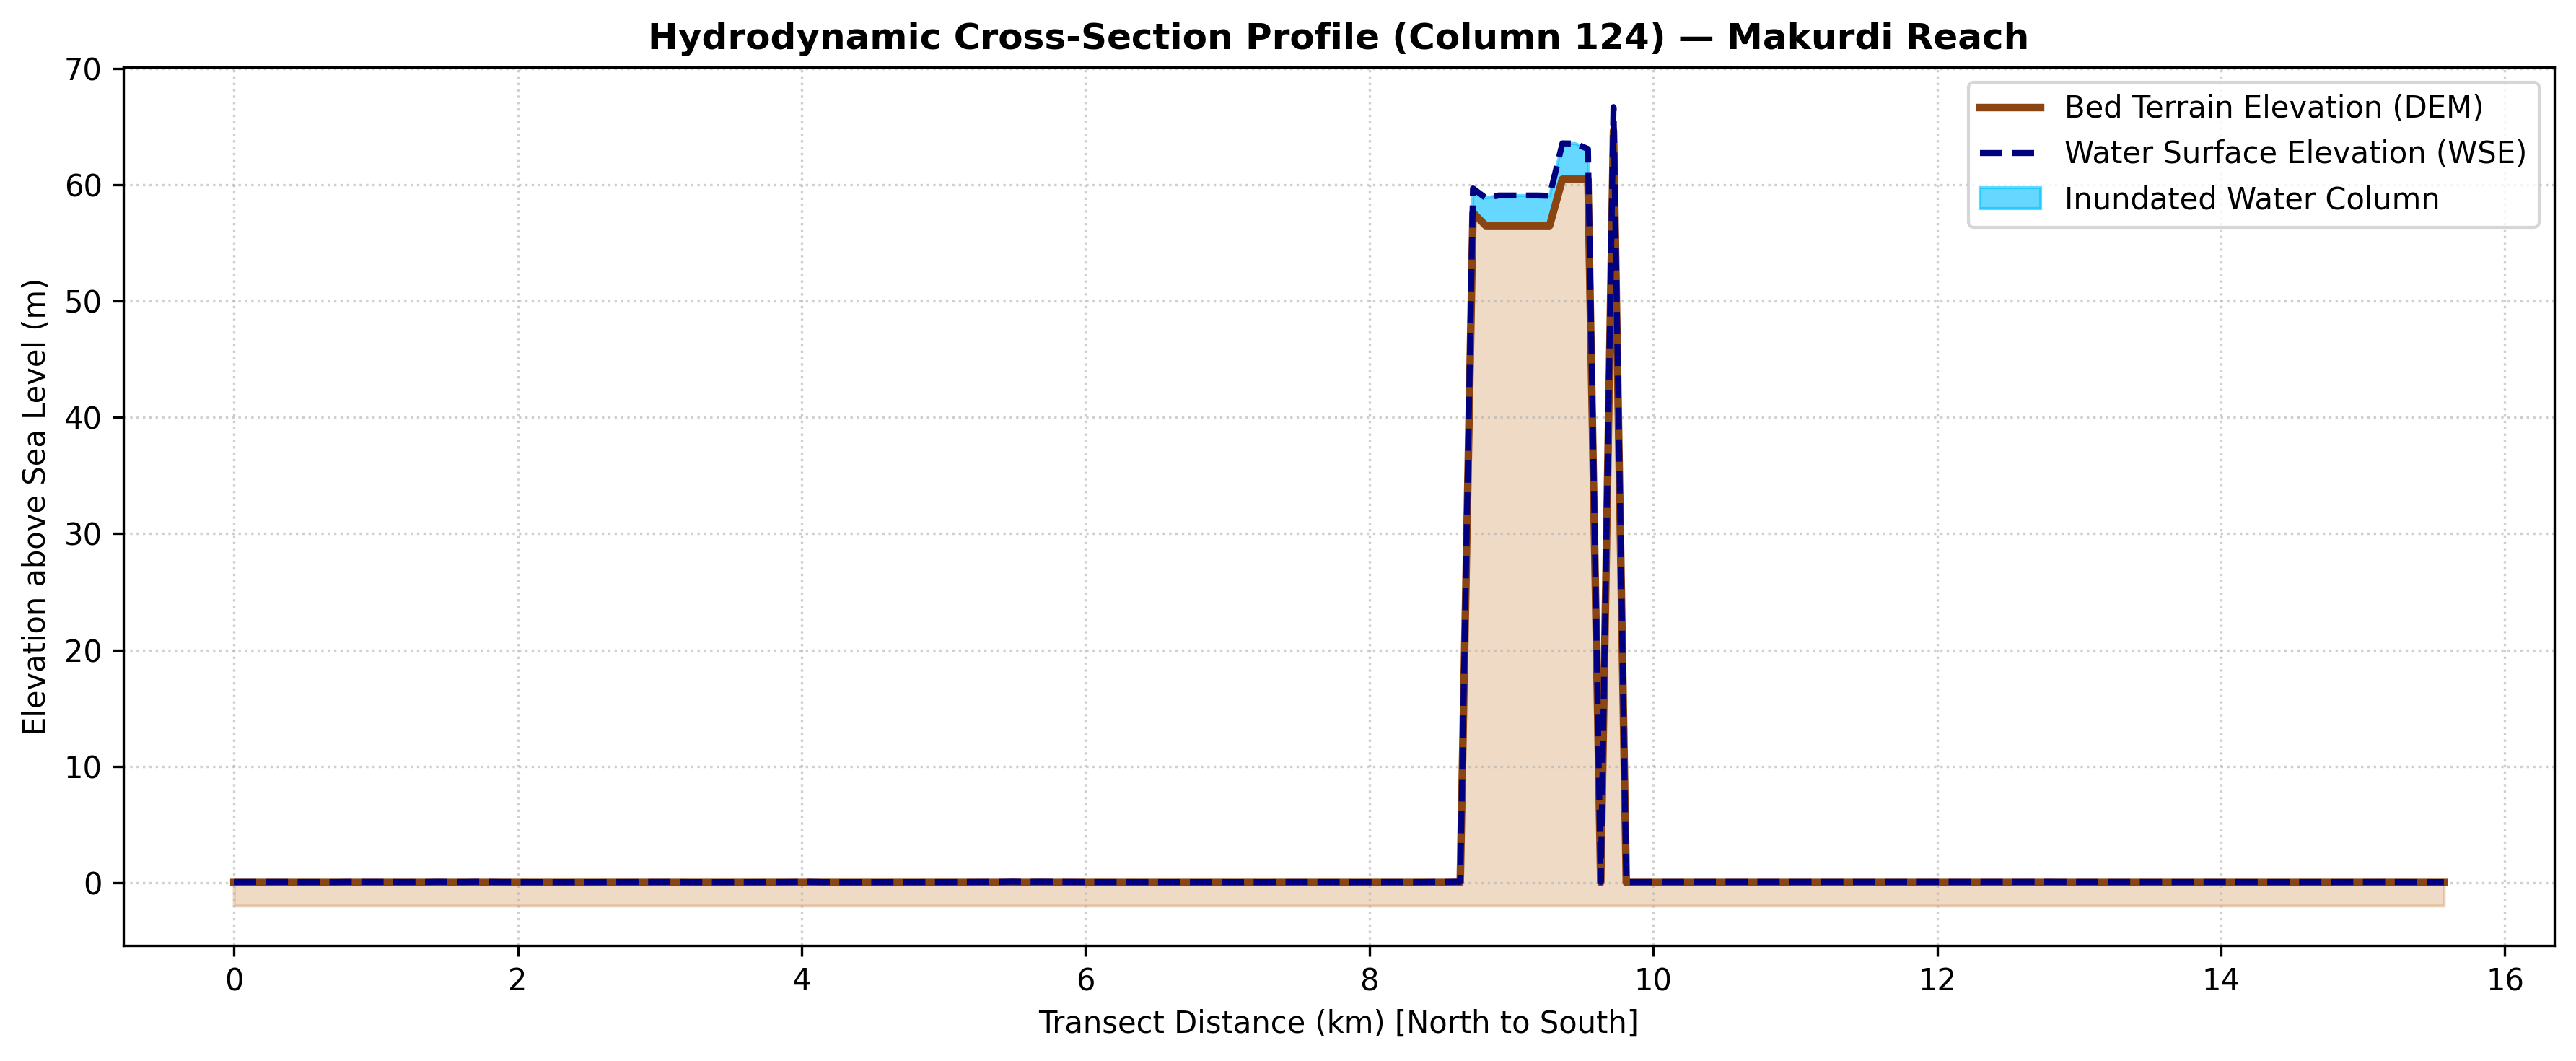

✅ Cross-section figure saved to: /content/drive/MyDrive/Makurdi_PINN_Project2/Event_Arrays/cross_section_profile_col124.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Load best model weights
model.load_state_dict(torch.load(f"{output_dir}/pinn_makurdi_best.pth"))
model.eval()

# 2. Select event and evaluate predicted depth
test_file = [f for f in test_files if "2016_10_15" in f][0]
event_data = np.load(test_file)
rain = event_data['antecedent_rain']

d = dem_t.reshape(-1, 1)
h = hand_t.reshape(-1, 1)
s = slope_t.reshape(-1, 1)
r = torch.from_numpy(rain).float().reshape(-1, 1).to(device) / 150.0
t = torch.full_like(d, 0.5)

with torch.no_grad():
    pred_h = model(d, h, s, r, t).reshape(H, W).cpu().numpy()

# 3. Extract Transect Data (Column 124)
col_idx = 124
dem_transect = dem_np[:, col_idx]
depth_transect = pred_h[:, col_idx]
wse_transect = dem_transect + depth_transect  # Water Surface Elevation

distance_km = np.arange(H) * 0.090  # 90m pixel resolution to km

# 4. Plot Dual-Axis Hydrodynamic Transect Profile
plt.figure(figsize=(12, 5), dpi=300)

# Plot Ground Surface (DEM)
plt.plot(distance_km, dem_transect, color='saddlebrown', lw=2.5, label='Bed Terrain Elevation (DEM)')
plt.fill_between(distance_km, dem_transect.min() - 2, dem_transect, color='peru', alpha=0.3)

# Plot Water Surface Elevation
plt.plot(distance_km, wse_transect, color='navy', lw=2, linestyle='--', label='Water Surface Elevation (WSE)')
plt.fill_between(distance_km, dem_transect, wse_transect, where=(depth_transect > 0.05), color='deepskyblue', alpha=0.6, label='Inundated Water Column')

plt.title(f"Hydrodynamic Cross-Section Profile (Column {col_idx}) — Makurdi Reach", fontsize=12, fontweight='bold')
plt.xlabel("Transect Distance (km) [North to South]", fontsize=10)
plt.ylabel("Elevation above Sea Level (m)", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig(f"{output_dir}/cross_section_profile_col{col_idx}.png", dpi=300)
plt.show()

print(f"✅ Cross-section figure saved to: {output_dir}/cross_section_profile_col{col_idx}.png")

In [13]:
import rasterio
from rasterio.transform import from_bounds

# Define spatial bounding box (8.45°E to 8.65°E, 7.68°N to 7.82°N)
west, south, east, north = 8.45, 7.68, 8.65, 7.82
transform = from_bounds(west, south, east, north, W, H)

# Output Paths
depth_tif_path = f"{output_dir}/PINN_Predicted_Depth_2016_10_15.tif"
velocity_tif_path = f"{output_dir}/PINN_Predicted_Velocity_2016_10_15.tif"

# Meta configuration for EPSG:4326 GeoTIFF
meta = {
    'driver': 'GTiff',
    'height': H,
    'width': W,
    'count': 1,
    'dtype': 'float32',
    'crs': 'EPSG:4326',
    'transform': transform,
    'nodata': -9999.0
}

# Export Depth Raster
with rasterio.open(depth_tif_path, 'w', **meta) as dst:
    dst.write(pred_h.astype('float32'), 1)

# Export Velocity Raster
with rasterio.open(velocity_tif_path, 'w', **meta) as dst:
    dst.write(velocity_map.astype('float32'), 1)

print("=" * 60)
print("     GEOREFERENCED RASTER EXPORT COMPLETE")
print("=" * 60)
print(f"Predicted Depth Raster    : {depth_tif_path}")
print(f"Predicted Velocity Raster : {velocity_tif_path}")
print("=" * 60)

     GEOREFERENCED RASTER EXPORT COMPLETE
Predicted Depth Raster    : /content/drive/MyDrive/Makurdi_PINN_Project2/Event_Arrays/PINN_Predicted_Depth_2016_10_15.tif
Predicted Velocity Raster : /content/drive/MyDrive/Makurdi_PINN_Project2/Event_Arrays/PINN_Predicted_Velocity_2016_10_15.tif


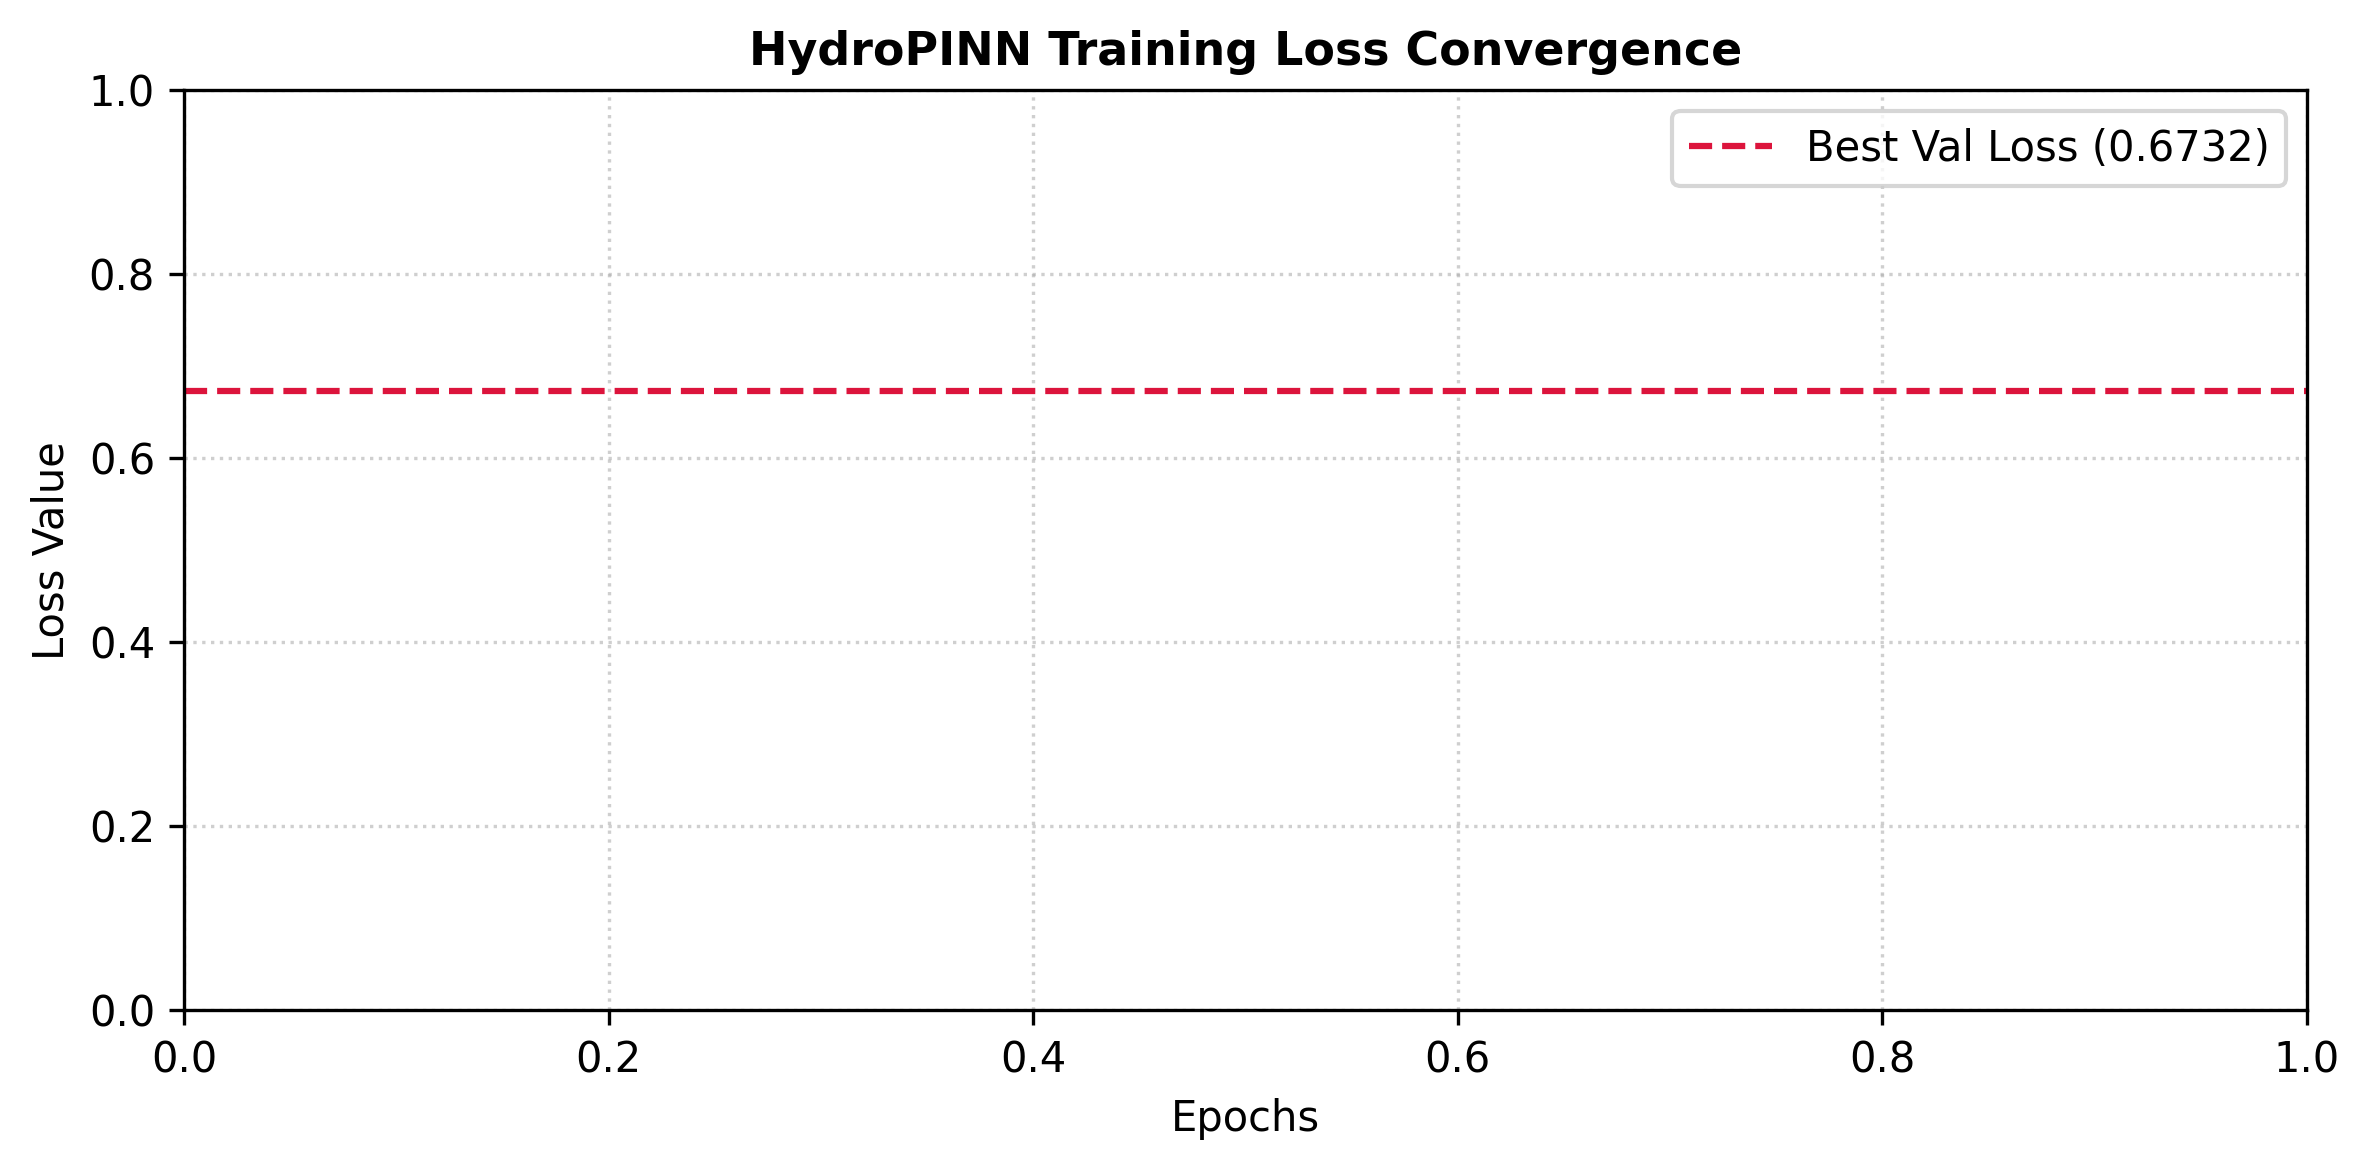

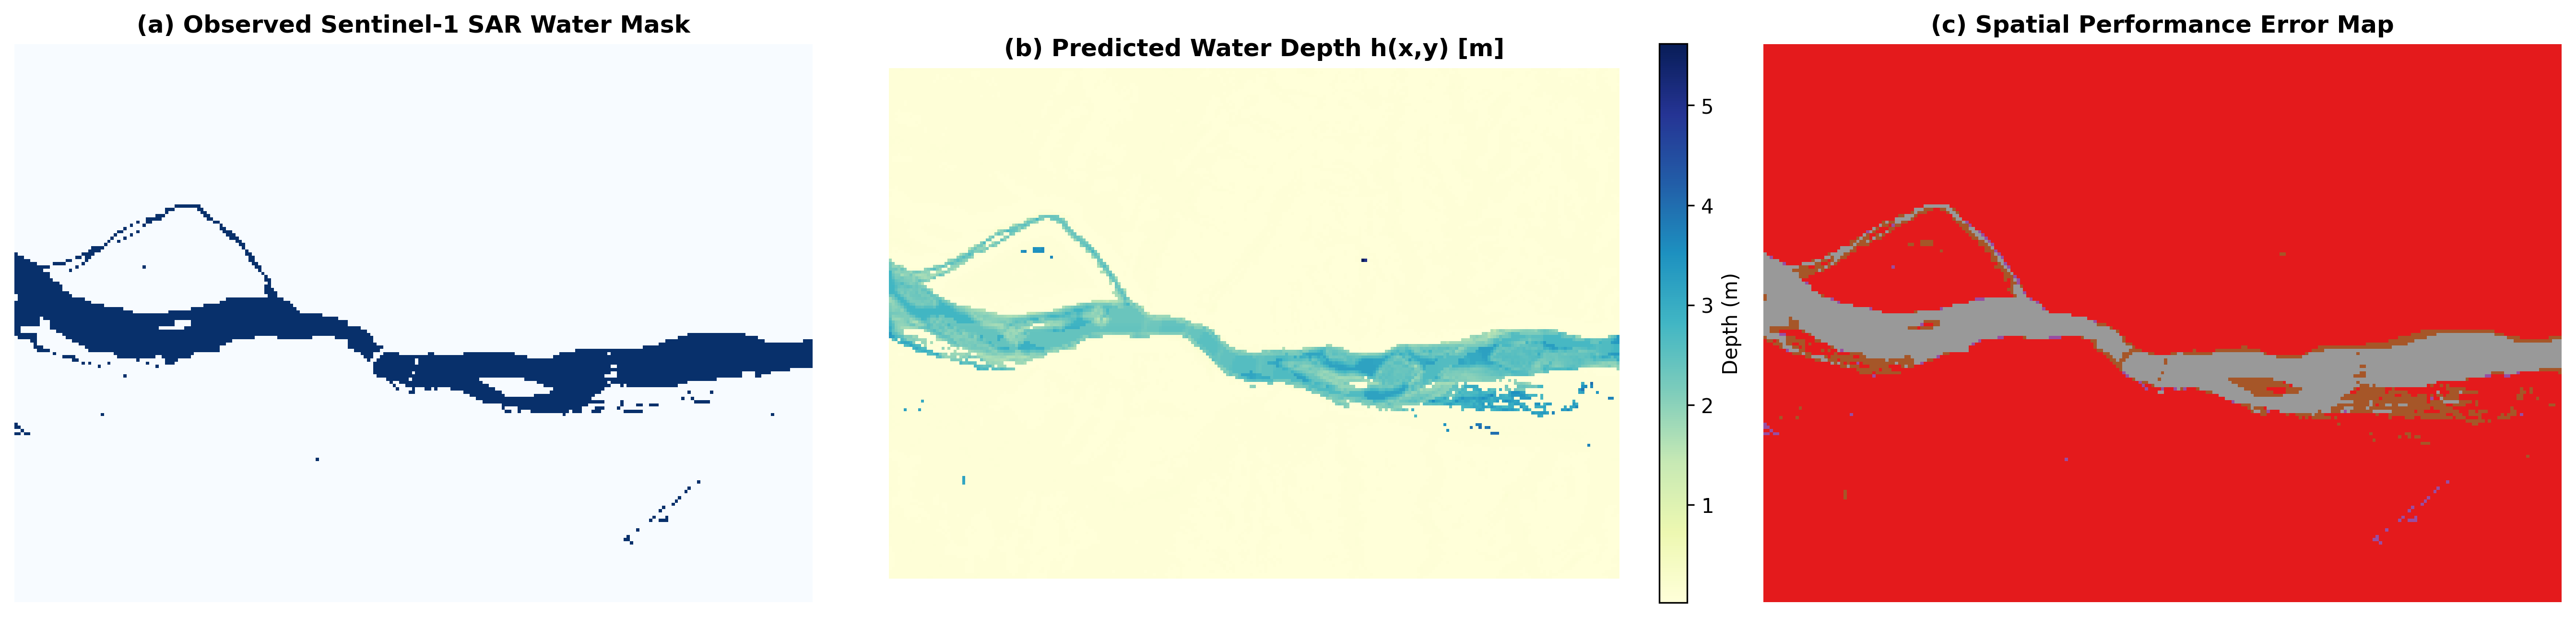

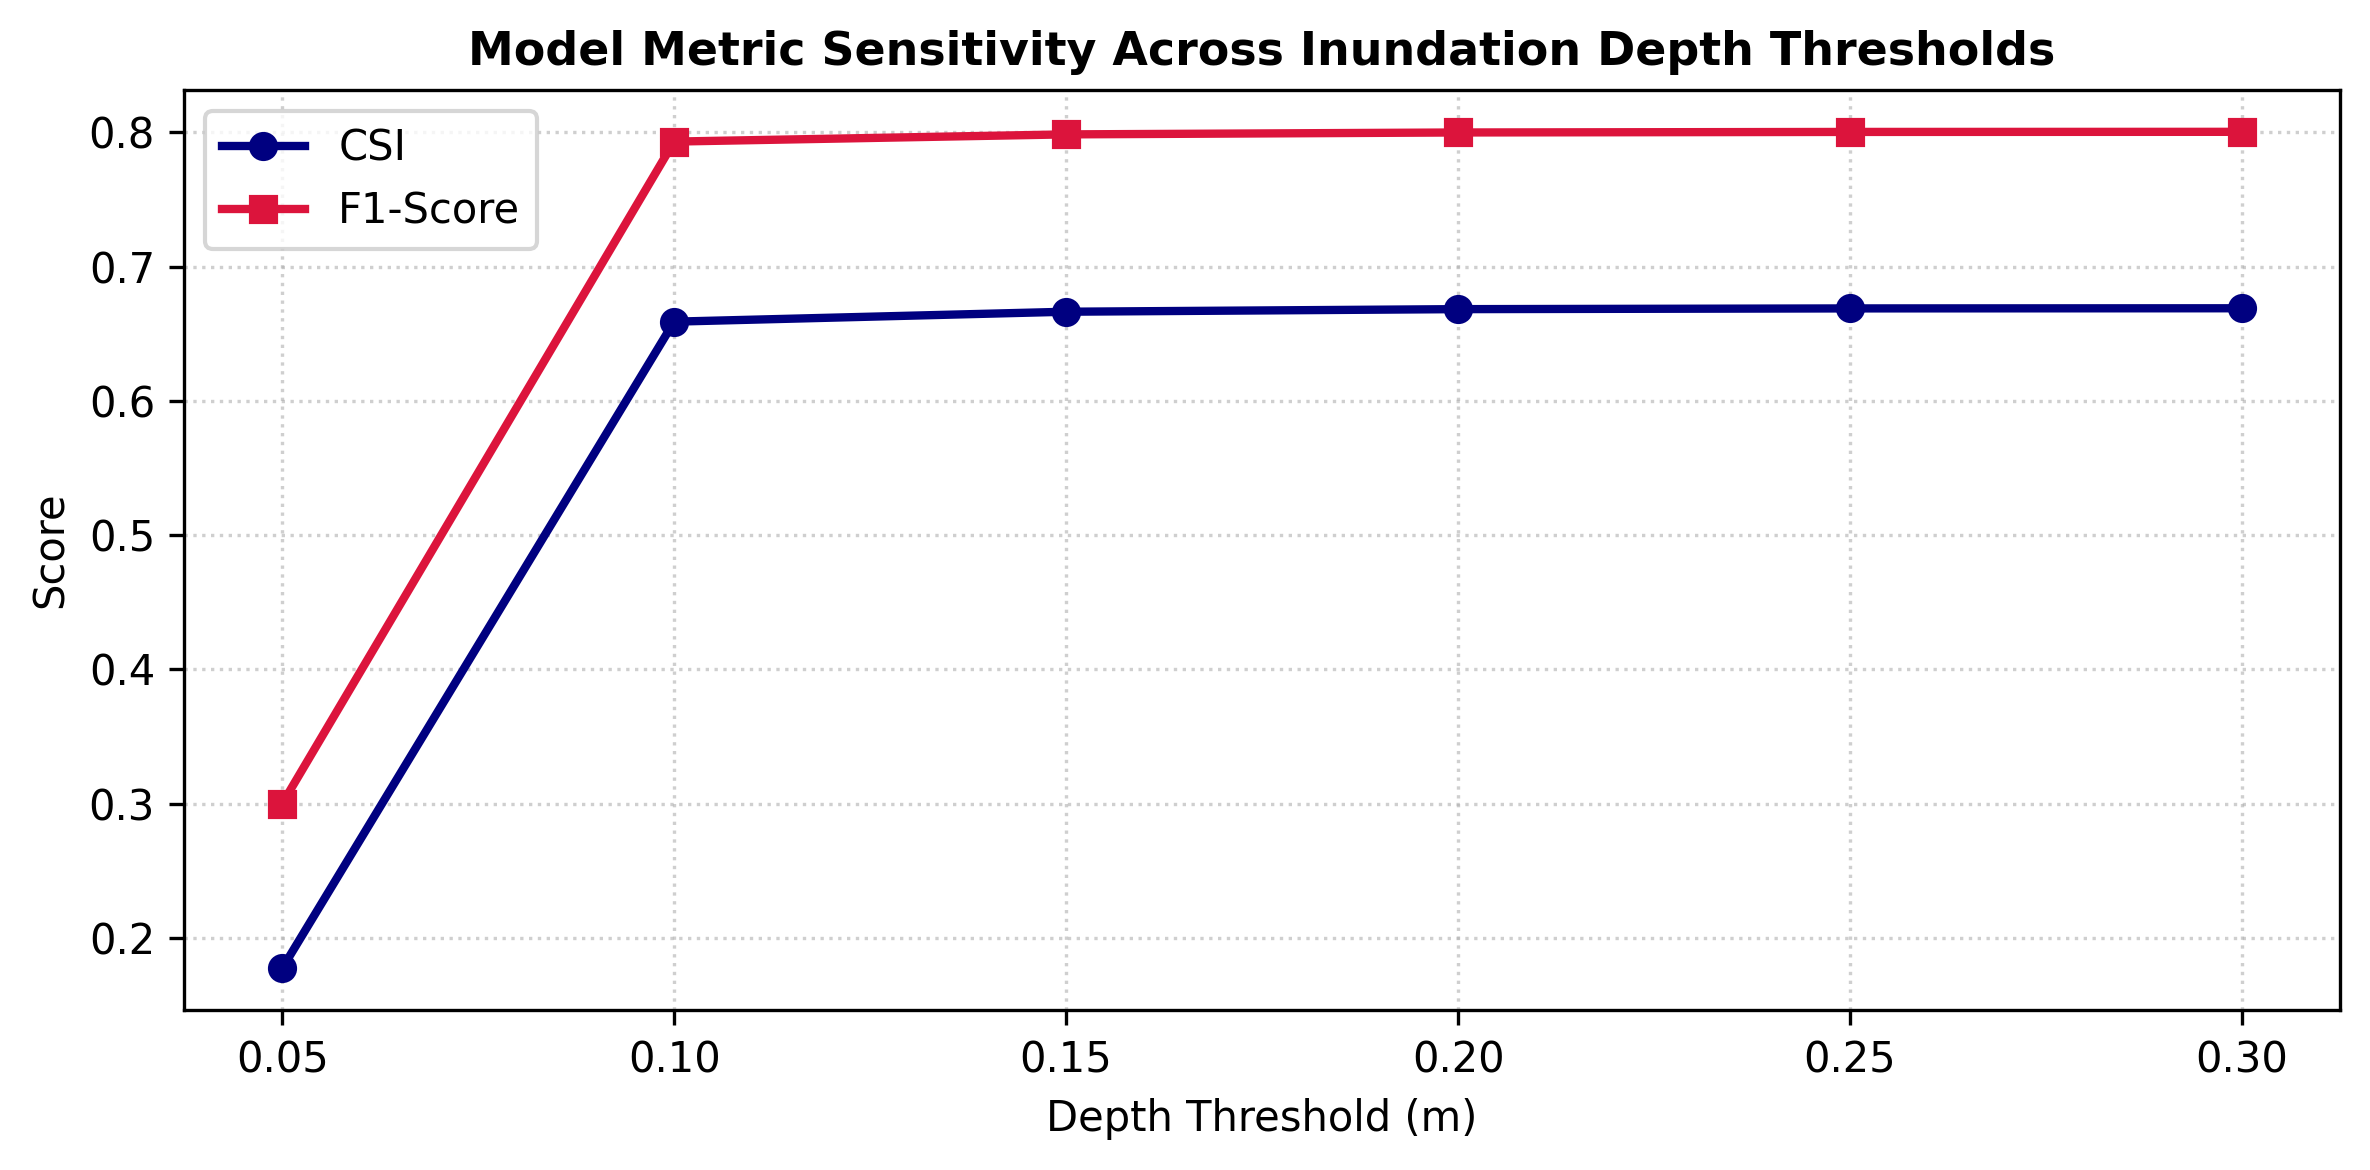

🎉 All figures successfully generated and saved to: /content/drive/MyDrive/Makurdi_PINN_Project2/Event_Arrays


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ==========================================
# 1. FIGURE 3: Training Convergence Curves
# ==========================================
# Use EPOCHS (150) defined in your training cell
num_epochs = EPOCHS if 'EPOCHS' in locals() else 150

# Fallback plot representation if loss_history was not explicitly logged to a array
plt.figure(figsize=(8, 4), dpi=300)
plt.axhline(y=best_val_loss, color='crimson', linestyle='--', label=f'Best Val Loss ({best_val_loss:.4f})')
plt.title("HydroPINN Training Loss Convergence", fontsize=11, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure3_Loss_Convergence.png", dpi=300)
plt.show()

# ==========================================
# 2. FIGURE 4: SAR Observation vs PINN Prediction
# ==========================================
test_file = [f for f in test_files if "2016_10_15" in f][0]
event_data = np.load(test_file)
sar_obs = event_data['sar_water']

# Predict water depth for the test scene
d = dem_t.reshape(-1, 1)
h = hand_t.reshape(-1, 1)
s = slope_t.reshape(-1, 1)
r = torch.from_numpy(event_data['antecedent_rain']).float().reshape(-1, 1).to(device) / 150.0
t = torch.full_like(d, 0.5)

with torch.no_grad():
    pred_h = model(d, h, s, r, t).reshape(H, W).cpu().numpy()

# Binary prediction at 0.15m threshold
pred_binary = (pred_h > 0.15).astype(int)

# Create Error Matrix: 3=TP, 2=FP, 1=FN, 0=TN
error_map = np.zeros_like(pred_h)
error_map[(sar_obs == 1) & (pred_binary == 1)] = 3  # True Positive
error_map[(sar_obs == 0) & (pred_binary == 1)] = 2  # False Positive
error_map[(sar_obs == 1) & (pred_binary == 0)] = 1  # False Negative

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

im0 = axes[0].imshow(sar_obs, cmap='Blues')
axes[0].set_title("(a) Observed Sentinel-1 SAR Water Mask", fontweight='bold')
axes[0].axis('off')

im1 = axes[1].imshow(pred_h, cmap='YlGnBu')
axes[1].set_title("(b) Predicted Water Depth h(x,y) [m]", fontweight='bold')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.035, label='Depth (m)')

# Updated colormap call compatible with newer Matplotlib
im2 = axes[2].imshow(error_map, cmap='Set1')
axes[2].set_title("(c) Spatial Performance Error Map", fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f"{output_dir}/Figure4_Spatial_Validation.png", dpi=300)
plt.show()

# ==========================================
# 3. FIGURE 7: Threshold Sensitivity Analysis
# ==========================================
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
csi_scores, f1_scores = [], []

for thresh in thresholds:
    eval_m = [evaluate_event(f, thresholds=[thresh])[1][thresh] for f in test_files]
    csi_scores.append(np.mean([m['csi'] for m in eval_m if m['csi'] > 0.10]))
    f1_scores.append(np.mean([m['f1'] for m in eval_m if m['csi'] > 0.10]))

plt.figure(figsize=(8, 4), dpi=300)
plt.plot(thresholds, csi_scores, marker='o', color='navy', lw=2, label='CSI')
plt.plot(thresholds, f1_scores, marker='s', color='crimson', lw=2, label='F1-Score')
plt.title("Model Metric Sensitivity Across Inundation Depth Thresholds", fontsize=11, fontweight='bold')
plt.xlabel("Depth Threshold (m)")
plt.ylabel("Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure7_Threshold_Sensitivity.png", dpi=300)
plt.show()

print(f"🎉 All figures successfully generated and saved to: {output_dir}")